In [1]:
import sys
!{sys.executable} -m pip install scikit-learn

'c:\Program' is not recognized as an internal or external command,
operable program or batch file.


# Climate Change Trend Analysis and Forecasting

## IDEAS TIH Summer Internship 2026

### Objective

This project analyzes greenhouse gas (GHG) emissions using the Our World in Data (OWID) dataset. The aim is to understand historical emission trends, perform exploratory data analysis, engineer predictive features, develop forecasting models, and present insights through visualizations.

# Table of Contents

1. Project Overview
2. Objectives
3. Dataset Description
4. Week 1 – Data Loading and Exploratory Data Analysis
5. Week 2 – Feature Engineering
6. Week 3 – Machine Learning Models
   - Naive Baseline
   - Linear Regression
   - Random Forest
7. Week 4 – ETS Forecasting
8. Model Comparison
9. Key Findings
10. Recommendations
11. Conclusion
12. References

In [2]:
print("Project Started Successfully!")

Project Started Successfully!


In [3]:
# ================================
# Import Required Libraries
# ================================

# Data manipulation
# ================================
# Import Required Libraries
# ================================

# Install missing library in notebook environment
%pip install pandas

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import plotly.express as px

print("Libraries Imported Successfully!")
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import plotly.express as px
import importlib, subprocess, sys

if importlib.util.find_spec("seaborn") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])

import seaborn as sns

plt.style.use("ggplot")

print("Libraries Imported Successfully!")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ModuleNotFoundError: No module named 'matplotlib'

## Load the Dataset

In this section, we load the OWID CO₂ emissions dataset into a Pandas DataFrame. A DataFrame is similar to an Excel spreadsheet, where rows represent observations and columns represent variables.

In [ ]:
# Load the dataset
df = pd.read_csv("../data/raw/owid-co2-data.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Dataset Shape

The dataset shape tells us the total number of rows (observations) and columns (variables).

In [ ]:
print("Dataset Shape")
print(df.shape)

Dataset Shape
(50411, 79)


## Column Names

This section lists all the variables available in the dataset.

In [ ]:
df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2',
       'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct',
       'co2_including_luc', 'co2_including_luc_growth_abs',
       'co2_including_luc_growth_prct', 'co2_including_luc_per_capita',
       'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy',
       'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2',
       'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita',
       'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2',
       'cumulative_co2_including_luc', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2',
       'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita',
       'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2',
       'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita',
       'land_use_change_co2', 'land_use_chang

## Data Types

This section shows the data type of every column.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  str    
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  str    
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc                

## Summary Statistics

This section summarizes the numerical columns using statistics such as mean, minimum, maximum, and standard deviation.

In [ ]:
df.describe()

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,...,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017294e+07,3.300495e+11,7.890109,0.060026,420.227035,6.268847,42.598225,544.144592,7.483698,...,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308412e+08,3.086383e+12,62.988171,0.123566,1972.092032,62.199548,1721.913018,2273.281696,99.512520,...,17.448980,9.282343,0.015362,0.045687,0.062888,0.003048,2414.076755,1812.363570,259.018184,62.637598
min,1750.000000,2.150000e+02,4.998000e+07,0.000000,0.000000,0.000000,-1928.339000,-100.000000,-84.560000,-2298.978000,...,0.000000,-0.824000,-0.001000,0.000000,-0.001000,0.000000,-19.725000,0.000000,-2177.807000,-98.281000
25%,1875.000000,3.272140e+05,7.874038e+09,0.000000,0.000000,0.381000,-0.005000,-1.070500,6.667750,-0.727500,...,0.144000,0.003000,0.000000,0.000000,0.000000,0.000000,1.502000,0.221000,-2.262250,-6.828750
50%,1925.000000,2.291264e+06,2.743861e+10,0.000000,0.001000,5.081000,0.044000,3.813000,28.120000,0.112000,...,0.588500,0.081000,0.000000,0.000000,0.000000,0.000000,14.605500,2.222000,1.641000,8.381500
75%,1975.000000,9.986553e+06,1.212627e+11,0.524000,0.077000,53.656500,1.018000,10.884000,124.303250,2.765250,...,2.416500,0.373000,0.000000,0.001000,0.002000,0.000000,76.508500,27.863000,11.425500,32.782250
max,2024.000000,8.161973e+09,1.301126e+14,1666.885000,2.484000,38598.578000,1804.657000,180870.000000,43184.086000,2614.874000,...,100.000000,100.000000,0.377000,1.216000,1.678000,0.085000,54433.398000,43714.777000,1768.846000,1023.042000


## Unique Countries and Entities

Before cleaning the dataset, we first examine all unique countries and entities available. This helps identify aggregate regions (e.g., World, Asia, Europe) that should be removed before analysis.

In [ ]:
print("Number of Unique Countries/Entities:")
print(df["country"].nunique())

Number of Unique Countries/Entities:
254


In [ ]:
countries = sorted(df["country"].unique())

for country in countries:
    print(country)

Afghanistan
Africa
Africa (GCP)
Albania
Algeria
Andorra
Angola
Anguilla
Antarctica
Antigua and Barbuda
Argentina
Armenia
Aruba
Asia
Asia (GCP)
Asia (excl. China and India)
Australia
Austria
Azerbaijan
Bahamas
Bahrain
Bangladesh
Barbados
Belarus
Belgium
Belize
Benin
Bermuda
Bhutan
Bolivia
Bonaire Sint Eustatius and Saba
Bosnia and Herzegovina
Botswana
Brazil
British Virgin Islands
Brunei
Bulgaria
Burkina Faso
Burundi
Cambodia
Cameroon
Canada
Cape Verde
Central African Republic
Central America (GCP)
Chad
Chile
China
Christmas Island
Colombia
Comoros
Congo
Cook Islands
Costa Rica
Cote d'Ivoire
Croatia
Cuba
Curacao
Cyprus
Czechia
Democratic Republic of Congo
Denmark
Djibouti
Dominica
Dominican Republic
East Timor
Ecuador
Egypt
El Salvador
Equatorial Guinea
Eritrea
Estonia
Eswatini
Ethiopia
Europe
Europe (GCP)
Europe (excl. EU-27)
Europe (excl. EU-28)
European Union (27)
European Union (28)
Faroe Islands
Fiji
Finland
France
French Polynesia
Gabon
Gambia
Georgia
Germany
Ghana
Greece
Greenlan

## Description of Key Variables

The following variables are used throughout this project:

- **country:** Name of the country or geographical entity.
- **year:** Calendar year of the recorded emissions.
- **co2:** Total carbon dioxide (CO₂) emissions measured in million tonnes.
- **co2_per_capita:** Average CO₂ emissions produced per person.
- **methane:** Methane (CH₄) emissions expressed in million tonnes of CO₂ equivalent.
- **nitrous_oxide:** Nitrous oxide (N₂O) emissions expressed in million tonnes of CO₂ equivalent.
- **total_ghg:** Total greenhouse gas emissions including CO₂, methane and nitrous oxide.

# Data Cleaning

## Filtering the Dataset

The original dataset contains 254 entities, including countries, regions, and economic groups. For this project, we retain only the ten countries specified in the internship scope and data from 1990 onwards. This ensures consistency in the analysis and forecasting tasks.

In [ ]:
# Countries selected for the project

project_countries = [
    "China",
    "United States",
    "India",
    "Russia",
    "Japan",
    "Germany",
    "Brazil",
    "United Kingdom",
    "South Africa",
    "Australia"
]

project_countries

['China',
 'United States',
 'India',
 'Russia',
 'Japan',
 'Germany',
 'Brazil',
 'United Kingdom',
 'South Africa',
 'Australia']

In [ ]:
# Keep only the selected countries

df_clean = df[df["country"].isin(project_countries)]

df_clean.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
3404,Australia,1750,AUS,314500.0,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3405,Australia,1751,AUS,NaN,NaN,NaN,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3406,Australia,1752,AUS,NaN,NaN,NaN,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3407,Australia,1753,AUS,NaN,NaN,NaN,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3408,Australia,1754,AUS,NaN,NaN,NaN,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Keep data from 1990 onwards

df_clean = df_clean[df_clean["year"] >= 1990]

df_clean.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
3644,Australia,1990,AUS,17126304.0,4.641366e+11,3.463,0.202,278.061,21.223,8.263,...,0.666,1.693,0.007,0.008,0.017,0.002,538.479,336.927,-33.380,-12.005
3645,Australia,1991,AUS,17353191.0,4.613021e+11,3.183,0.183,279.437,1.376,0.495,...,0.643,1.687,0.007,0.008,0.017,0.002,522.525,339.829,-34.011,-12.171
3646,Australia,1992,AUS,17549286.0,4.786337e+11,2.923,0.167,284.433,4.996,1.788,...,0.699,1.680,0.007,0.008,0.017,0.002,568.962,346.607,-36.367,-12.786
3647,Australia,1993,AUS,17722905.0,5.015248e+11,3.005,0.170,288.780,4.347,1.528,...,0.810,1.677,0.007,0.008,0.017,0.002,580.666,350.855,-40.004,-13.853
3648,Australia,1994,AUS,17897433.0,5.279932e+11,3.484,0.195,293.613,4.833,1.674,...,0.924,1.671,0.007,0.008,0.018,0.002,554.084,353.411,-35.667,-12.148


In [ ]:
print("Shape of Clean Dataset:")
print(df_clean.shape)

print("\nCountries Included:")
print(df_clean["country"].unique())

print("\nYear Range:")
print(df_clean["year"].min(), "-", df_clean["year"].max())

Shape of Clean Dataset:
(350, 79)

Countries Included:
<StringArray>
[     'Australia',         'Brazil',          'China',        'Germany',
          'India',          'Japan',         'Russia',   'South Africa',
 'United Kingdom',  'United States']
Length: 10, dtype: str

Year Range:
1990 - 2024


# Data Profiling

## Missing Value Analysis

Before performing exploratory data analysis, it is important to examine missing values in the variables used for the study. This helps identify whether any preprocessing is required before visualization and modelling.

In [ ]:
# Important columns for the project

important_columns = [
    "country",
    "year",
    "co2",
    "co2_per_capita",
    "methane",
    "nitrous_oxide",
    "total_ghg",
    "population",
    "gdp"
]

# Missing value analysis

missing = df_clean[important_columns].isnull().sum().to_frame(name="Missing Values")

missing["Percentage (%)"] = (
    missing["Missing Values"] / len(df_clean) * 100
).round(2)

missing

,Missing Values,Percentage (%)
country,0,0.00
year,0,0.00
co2,0,0.00
co2_per_capita,0,0.00
methane,0,0.00
nitrous_oxide,0,0.00
total_ghg,0,0.00
population,0,0.00
gdp,20,5.71


## Data Coverage by Country

This section examines the number of observations available for each country in the original dataset. Understanding data coverage helps identify countries with the most complete historical records before filtering the dataset.

In [ ]:
country_coverage = (
    df.groupby("country")
      .size()
      .reset_index(name="Number of Records")
      .sort_values(by="Number of Records", ascending=False)
)

country_coverage.head(15)

,country,Number of Records
0,Afghanistan,275
1,Africa,275
5,Andorra,275
8,Antarctica,275
13,Asia,275
15,Asia (excl. China and India),275
21,Bangladesh,275
22,Barbados,275
28,Bhutan,275
29,Bolivia,275


# Exploratory Data Analysis (EDA)

## Global CO₂ Emissions Over Time

This visualization shows the trend of global carbon dioxide (CO₂) emissions over time using the **World** data from the original dataset. It helps identify long-term changes in global emissions and provides an overview of historical emission patterns.

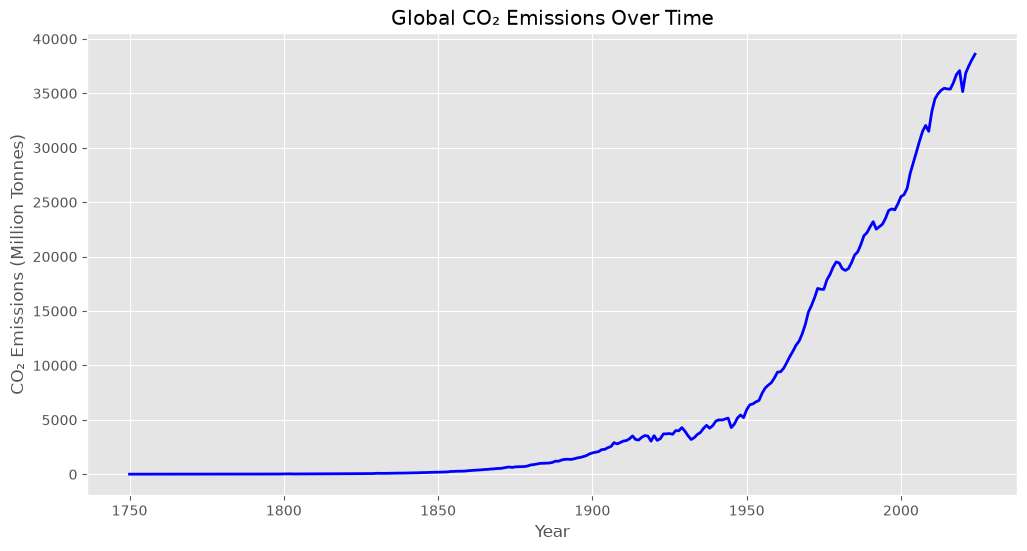

In [ ]:
# Select World data
world_data = df[df["country"] == "World"]

# Plot Global CO₂ Emissions

plt.figure(figsize=(12,6))

plt.plot(
    world_data["year"],
    world_data["co2"],
    color="blue",
    linewidth=2
)

plt.title("Global CO₂ Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Million Tonnes)")
plt.grid(True)

plt.show()

### Observation

Global CO₂ emissions show a clear increasing trend over time, reflecting the growth of industrialization, energy consumption, and economic development worldwide. Although there are short periods of slower growth or temporary declines, the overall pattern indicates a substantial rise in emissions over the historical period. This trend highlights the increasing impact of human activities on climate change.

## CO₂ Emissions Comparison of Major Emitting Countries

This visualization compares the CO₂ emission trends of five major emitting countries: China, the United States, India, Russia, and Japan. Comparing these countries helps identify differences in emission patterns and understand their contribution to global greenhouse gas emissions over time.

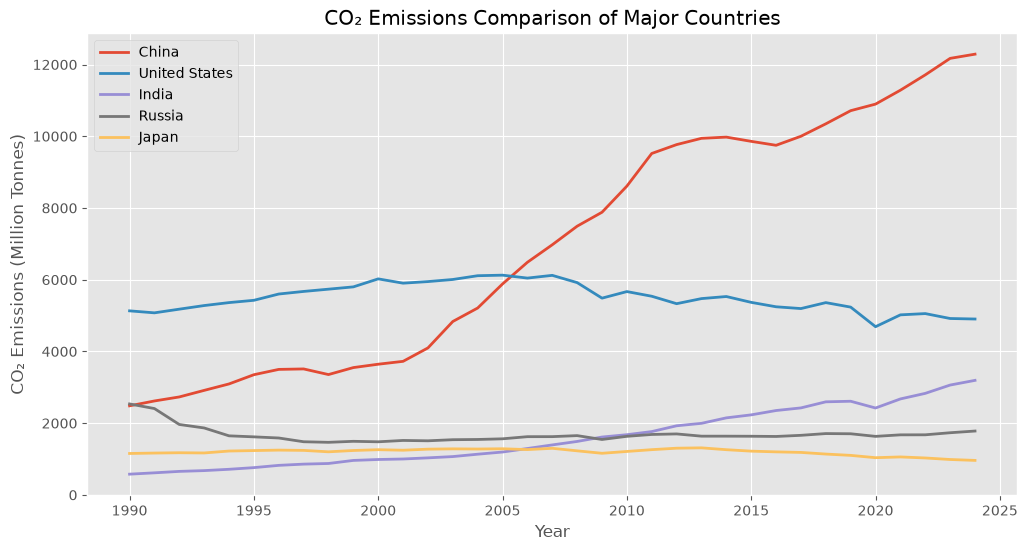

In [ ]:
# Countries to compare
comparison_countries = [
    "China",
    "United States",
    "India",
    "Russia",
    "Japan"
]

# Filter data
comparison_data = df_clean[df_clean["country"].isin(comparison_countries)]

# Plot

plt.figure(figsize=(12,6))

for country in comparison_countries:
    country_data = comparison_data[comparison_data["country"] == country]

    plt.plot(
        country_data["year"],
        country_data["co2"],
        label=country,
        linewidth=2
    )

plt.title("CO₂ Emissions Comparison of Major Countries")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Million Tonnes)")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The chart shows noticeable differences in CO₂ emission trends among the five countries. China experiences a rapid increase in emissions, particularly after the early 2000s, while the United States shows relatively stable or slightly declining emissions in recent years. India displays a steady upward trend, whereas Russia and Japan have comparatively lower emission levels with slower changes over time. These differences reflect variations in industrial growth, energy demand, and economic development.

## Greenhouse Gas Emissions by Decade

This visualization compares the average emissions of the three major greenhouse gases—Carbon Dioxide (CO₂), Methane (CH₄), and Nitrous Oxide (N₂O)—across different decades. It helps identify long-term emission trends and understand how greenhouse gas emissions have changed over time.

In [ ]:
# Create decade column
df["decade"] = (df["year"] // 10) * 10

# Calculate average greenhouse gas emissions by decade
decade_data = (
    df.groupby("decade")[["co2", "methane", "nitrous_oxide"]]
      .mean()
      .reset_index()
)

decade_data

,decade,co2,methane,nitrous_oxide
0,1750,4.196314,NaN,NaN
1,1760,4.959514,NaN,NaN
2,1770,6.113186,NaN,NaN
3,1780,6.876645,NaN,NaN
4,1790,7.264194,NaN,NaN
5,1800,9.456724,NaN,NaN
6,1810,12.016294,NaN,NaN
7,1820,15.330743,NaN,NaN
8,1830,17.076524,NaN,NaN
9,1840,29.895883,NaN,NaN


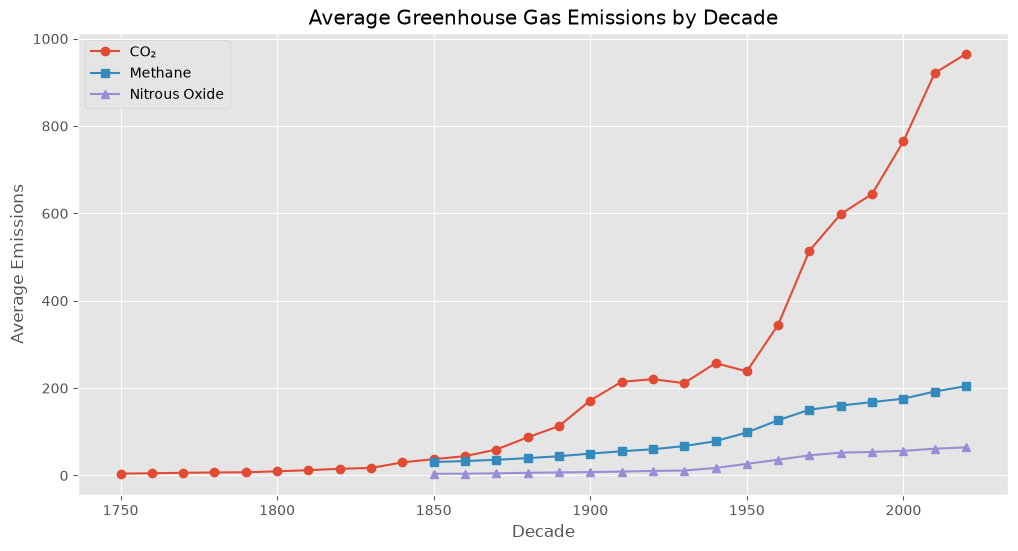

In [ ]:
# Plot average greenhouse gas emissions by decade

plt.figure(figsize=(12,6))

plt.plot(decade_data["decade"], decade_data["co2"],
         marker="o", label="CO₂")

plt.plot(decade_data["decade"], decade_data["methane"],
         marker="s", label="Methane")

plt.plot(decade_data["decade"], decade_data["nitrous_oxide"],
         marker="^", label="Nitrous Oxide")

plt.title("Average Greenhouse Gas Emissions by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Emissions")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The average emissions of greenhouse gases have generally increased across successive decades, although the rate of increase differs among the three gases. Carbon dioxide (CO₂) shows the most pronounced growth, reflecting its dominant contribution to global greenhouse gas emissions. Methane and nitrous oxide also exhibit long-term changes, highlighting the importance of considering multiple greenhouse gases when studying climate change.

# Feature Engineering

Feature engineering is the process of creating new variables from the existing dataset to improve data analysis and predictive modelling. These features help capture additional information that may improve the performance of forecasting models.

In [ ]:
# Create additional features

df_clean = df_clean.copy()

# Decade
df_clean["decade"] = (df_clean["year"] // 10) * 10

# CO₂ per GDP
df_clean["co2_per_gdp"] = df_clean["co2"] / df_clean["gdp"]

# Population in millions
df_clean["population_millions"] = df_clean["population"] / 1_000_000

# Display the first few rows
df_clean.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share,decade,population_millions
3644,Australia,1990,AUS,17126304.0,4.641366e+11,3.463,0.202,278.061,21.223,8.263,...,0.007,0.008,0.017,0.002,538.479,336.927,-33.380,-12.005,1990,17.126304
3645,Australia,1991,AUS,17353191.0,4.613021e+11,3.183,0.183,279.437,1.376,0.495,...,0.007,0.008,0.017,0.002,522.525,339.829,-34.011,-12.171,1990,17.353191
3646,Australia,1992,AUS,17549286.0,4.786337e+11,2.923,0.167,284.433,4.996,1.788,...,0.007,0.008,0.017,0.002,568.962,346.607,-36.367,-12.786,1990,17.549286
3647,Australia,1993,AUS,17722905.0,5.015248e+11,3.005,0.170,288.780,4.347,1.528,...,0.007,0.008,0.017,0.002,580.666,350.855,-40.004,-13.853,1990,17.722905
3648,Australia,1994,AUS,17897433.0,5.279932e+11,3.484,0.195,293.613,4.833,1.674,...,0.007,0.008,0.018,0.002,554.084,353.411,-35.667,-12.148,1990,17.897433


### Feature Description

Three new variables were created:

- **Decade**: Groups observations into decades for long-term trend analysis.
- **CO₂ per GDP**: Measures carbon dioxide emissions relative to economic output.
- **Population (Millions)**: Converts population values into millions for easier interpretation and visualization.

# Week 2: Feature Engineering

Feature engineering involves creating new variables from the existing dataset that can improve the performance of machine learning models. In this section, time-based, lag, intensity, and growth rate features are created to prepare the dataset for regression and forecasting models.

## 2.1 Time-Based Features

Time-based features help capture long-term trends in greenhouse gas emissions. These features include the decade of observation, the number of years since 1990, and a rolling average of CO₂ emissions over the previous five years.

In [ ]:
# Create a copy of the cleaned dataset
feature_df = df_clean.copy()

# Create decade column
feature_df["decade"] = (feature_df["year"] // 10) * 10

# Create years since 1990
feature_df["years_since_1990"] = feature_df["year"] - 1990

# Display first few rows
feature_df[["country", "year", "decade", "years_since_1990"]].head(10)

,country,year,decade,years_since_1990
3644,Australia,1990,1990,0
3645,Australia,1991,1990,1
3646,Australia,1992,1990,2
3647,Australia,1993,1990,3
3648,Australia,1994,1990,4
3649,Australia,1995,1990,5
3650,Australia,1996,1990,6
3651,Australia,1997,1990,7
3652,Australia,1998,1990,8
3653,Australia,1999,1990,9


### Observation

The new time-based features provide additional temporal information for the dataset. The **decade** column groups observations into decades, while **years_since_1990** creates a continuous numerical time index that is suitable for regression models and time-series forecasting.

### 5-Year Rolling Average of CO₂ Emissions

A rolling average smooths short-term fluctuations in the data by averaging values over a fixed time window. In this project, a 5-year rolling average of CO₂ emissions is calculated for each country to better capture long-term emission trends and reduce year-to-year variability.

In [ ]:
# Sort the dataset by country and year
feature_df = feature_df.sort_values(["country", "year"])

# Calculate 5-year rolling average of CO₂ emissions
feature_df["co2_5yr_rolling_mean"] = (
    feature_df.groupby("country")["co2"]
              .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

# Display the result
feature_df[
    ["country", "year", "co2", "co2_5yr_rolling_mean"]
].head(15)

,country,year,co2,co2_5yr_rolling_mean
3644,Australia,1990,278.061,278.061000
3645,Australia,1991,279.437,278.749000
3646,Australia,1992,284.433,280.643667
3647,Australia,1993,288.780,282.677750
3648,Australia,1994,293.613,284.864800
3649,Australia,1995,304.962,290.245000
3650,Australia,1996,311.851,296.727800
3651,Australia,1997,320.243,303.889800
3652,Australia,1998,334.038,312.941400
3653,Australia,1999,343.876,322.994000


### Observation

The 5-year rolling average smooths annual fluctuations in CO₂ emissions by averaging the current year and the previous four years for each country. This provides a clearer view of long-term emission trends and is useful for regression and forecasting models.

## 2.2 Lag Features

Lag features store values from previous years and are commonly used in time-series forecasting. They help machine learning models learn how past CO₂ emissions influence future emissions. In this project, lag features for the previous one, two, and three years are created for each country.

In [ ]:
# Create lag features for CO₂ emissions

feature_df["co2_lag1"] = (
    feature_df.groupby("country")["co2"].shift(1)
)

feature_df["co2_lag2"] = (
    feature_df.groupby("country")["co2"].shift(2)
)

feature_df["co2_lag3"] = (
    feature_df.groupby("country")["co2"].shift(3)
)

# Display the results
feature_df[
    [
        "country",
        "year",
        "co2",
        "co2_lag1",
        "co2_lag2",
        "co2_lag3"
    ]
].head(15)

,country,year,co2,co2_lag1,co2_lag2,co2_lag3
3644,Australia,1990,278.061,NaN,NaN,NaN
3645,Australia,1991,279.437,278.061,NaN,NaN
3646,Australia,1992,284.433,279.437,278.061,NaN
3647,Australia,1993,288.780,284.433,279.437,278.061
3648,Australia,1994,293.613,288.780,284.433,279.437
3649,Australia,1995,304.962,293.613,288.780,284.433
3650,Australia,1996,311.851,304.962,293.613,288.780
3651,Australia,1997,320.243,311.851,304.962,293.613
3652,Australia,1998,334.038,320.243,311.851,304.962
3653,Australia,1999,343.876,334.038,320.243,311.851


### Observation

The lag features store CO₂ emission values from the previous one, two, and three years for each country. The first few years for each country contain missing values because there are no earlier observations available. These lag variables provide historical information that improves the ability of forecasting and regression models to predict future emissions.

## 2.3 Per-Capita and Intensity Features

Per-capita and intensity features help compare greenhouse gas emissions across countries with different population sizes and economic output. In this section, the CO₂ per capita values are verified, and a greenhouse gas intensity feature is created using total greenhouse gas emissions and GDP.

In [ ]:
# Verify CO₂ per capita for 3 countries and 3 years

verification = feature_df[
    (feature_df["country"].isin(["China", "India", "United States"])) &
    (feature_df["year"].isin([1995, 2005, 2015]))
][
    ["country", "year", "co2", "population", "co2_per_capita"]
].copy()

# Calculate CO₂ per capita manually
verification["calculated_co2_per_capita"] = (
    verification["co2"] * 1_000_000 / verification["population"]
)

verification

,country,year,co2,population,co2_per_capita,calculated_co2_per_capita
9904,China,1995,3351.197,1.220134e+09,2.747,2.746581
9914,China,2005,5881.991,1.310027e+09,4.490,4.489976
9924,China,2015,9858.040,1.396134e+09,7.061,7.060955
21733,India,1995,760.480,9.603010e+08,0.792,0.791918
21743,India,2005,1195.393,1.154676e+09,1.035,1.035262
21753,India,2015,2231.817,1.328024e+09,1.681,1.680554
47978,United States,1995,5425.837,2.682058e+08,20.230,20.230126
47988,United States,2005,6126.903,2.957167e+08,20.719,20.718829
47998,United States,2015,5368.497,3.261265e+08,16.461,16.461395


In [ ]:
# Create GHG intensity feature

feature_df["ghg_intensity"] = (
    feature_df["total_ghg"] / feature_df["gdp"]
)

feature_df[
    [
        "country",
        "year",
        "total_ghg",
        "gdp",
        "ghg_intensity"
    ]
].head(10)

,country,year,total_ghg,gdp,ghg_intensity
3644,Australia,1990,538.479,4.641366e+11,1.160174e-09
3645,Australia,1991,522.525,4.613021e+11,1.132718e-09
3646,Australia,1992,568.962,4.786337e+11,1.188721e-09
3647,Australia,1993,580.666,5.015248e+11,1.157801e-09
3648,Australia,1994,554.084,5.279932e+11,1.049415e-09
3649,Australia,1995,672.727,5.490387e+11,1.225281e-09
3650,Australia,1996,677.191,5.747656e+11,1.178204e-09
3651,Australia,1997,649.422,6.014728e+11,1.079720e-09
3652,Australia,1998,705.618,6.348471e+11,1.111477e-09
3653,Australia,1999,710.665,6.645207e+11,1.069440e-09


In [ ]:
# Countries and years where GHG intensity cannot be calculated

missing_ghg = feature_df[
    feature_df["ghg_intensity"].isna()
][
    ["country", "year", "gdp"]
]

missing_ghg

,country,year,gdp
3677,Australia,2023,NaN
3678,Australia,2024,NaN
7211,Brazil,2023,NaN
7212,Brazil,2024,NaN
9932,China,2023,NaN
9933,China,2024,NaN
18318,Germany,2023,NaN
18319,Germany,2024,NaN
21761,India,2023,NaN
21762,India,2024,NaN


### Observation

The manually calculated CO₂ per capita values closely match the values provided in the dataset, confirming that the data is consistent. The greenhouse gas intensity feature was successfully created for records where GDP data is available. Some country-year combinations contain missing GDP values, so greenhouse gas intensity could not be calculated for those observations.

### Observation

The manually calculated CO₂ per capita values closely match the values provided in the dataset, confirming that the data is consistent. The greenhouse gas intensity feature was successfully created for records where GDP data is available. Some country-year combinations contain missing GDP values, so greenhouse gas intensity could not be calculated for those observations.

In [ ]:
# Calculate year-on-year absolute change
feature_df["co2_yoy_change"] = (
    feature_df.groupby("country")["co2"].diff()
)

# Calculate year-on-year percentage change
feature_df["co2_yoy_pct_change"] = (
    feature_df.groupby("country")["co2"].pct_change() * 100
)

# Display the results
feature_df[
    [
        "country",
        "year",
        "co2",
        "co2_yoy_change",
        "co2_yoy_pct_change"
    ]
].head(15)

,country,year,co2,co2_yoy_change,co2_yoy_pct_change
3644,Australia,1990,278.061,NaN,NaN
3645,Australia,1991,279.437,1.376,0.494855
3646,Australia,1992,284.433,4.996,1.787881
3647,Australia,1993,288.780,4.347,1.528304
3648,Australia,1994,293.613,4.833,1.673592
3649,Australia,1995,304.962,11.349,3.865292
3650,Australia,1996,311.851,6.889,2.258970
3651,Australia,1997,320.243,8.392,2.691029
3652,Australia,1998,334.038,13.795,4.307666
3653,Australia,1999,343.876,9.838,2.945174


In [ ]:
# Top 5 countries with highest average annual CO₂ growth rate

top_growth = (
    feature_df.groupby("country")["co2_yoy_pct_change"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

top_growth

country
India           5.207068
China           4.905114
Brazil          2.463847
South Africa    1.132051
Australia       0.990026
Name: co2_yoy_pct_change, dtype: float64

In [ ]:
# Top 5 countries with largest average CO₂ reductions

top_reduction = (
    feature_df.groupby("country")["co2_yoy_pct_change"]
    .mean()
    .sort_values()
    .head(5)
)

top_reduction

country
United Kingdom   -1.828321
Germany          -1.719618
Russia           -0.917672
Japan            -0.493131
United States    -0.080126
Name: co2_yoy_pct_change, dtype: float64

### Observation

The year-on-year growth rate features quantify how CO₂ emissions change from one year to the next. Positive values indicate an increase in emissions, while negative values indicate a reduction. The ranking of countries based on average annual growth rates highlights those with the fastest increases in emissions as well as those that have achieved the greatest reductions since 1990.

## 2.5 Final Feature Dataset

The engineered features created in the previous sections are combined into a final modelling dataset. This dataset contains the variables required for regression and time-series forecasting models in the following weeks. The final feature dataset is also exported as a CSV file for future use.

In [ ]:
# Select the required columns for the final feature dataset

final_features = feature_df[
    [
        "country",
        "year",
        "co2",
        "co2_per_capita",
        "co2_5yr_rolling_mean",
        "co2_lag1",
        "co2_lag2",
        "co2_lag3",
        "co2_yoy_pct_change",
        "ghg_intensity"
    ]
].copy()

# Display the first 10 rows
final_features.head(10)

,country,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity
3644,Australia,1990,278.061,16.236,278.061000,NaN,NaN,NaN,NaN,1.160174e-09
3645,Australia,1991,279.437,16.103,278.749000,278.061,NaN,NaN,0.494855,1.132718e-09
3646,Australia,1992,284.433,16.208,280.643667,279.437,278.061,NaN,1.787881,1.188721e-09
3647,Australia,1993,288.780,16.294,282.677750,284.433,279.437,278.061,1.528304,1.157801e-09
3648,Australia,1994,293.613,16.405,284.864800,288.780,284.433,279.437,1.673592,1.049415e-09
3649,Australia,1995,304.962,16.853,290.245000,293.613,288.780,284.433,3.865292,1.225281e-09
3650,Australia,1996,311.851,17.036,296.727800,304.962,293.613,288.780,2.258970,1.178204e-09
3651,Australia,1997,320.243,17.306,303.889800,311.851,304.962,293.613,2.691029,1.079720e-09
3652,Australia,1998,334.038,17.861,312.941400,320.243,311.851,304.962,4.307666,1.111477e-09
3653,Australia,1999,343.876,18.185,322.994000,334.038,320.243,311.851,2.945174,1.069440e-09


In [ ]:
# Save the final feature dataset

final_features.to_csv("ghg_features.csv", index=False)

print("Feature dataset saved successfully as 'ghg_features.csv'")

Feature dataset saved successfully as 'ghg_features.csv'


In [ ]:
# Check the dataset

print("Shape:", final_features.shape)

print("\nColumns:")
print(final_features.columns)

final_features.head()

Shape: (350, 10)

Columns:
Index(['country', 'year', 'co2', 'co2_per_capita', 'co2_5yr_rolling_mean',
       'co2_lag1', 'co2_lag2', 'co2_lag3', 'co2_yoy_pct_change',
       'ghg_intensity'],
      dtype='str')


,country,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity
3644,Australia,1990,278.061,16.236,278.061000,NaN,NaN,NaN,NaN,1.160174e-09
3645,Australia,1991,279.437,16.103,278.749000,278.061,NaN,NaN,0.494855,1.132718e-09
3646,Australia,1992,284.433,16.208,280.643667,279.437,278.061,NaN,1.787881,1.188721e-09
3647,Australia,1993,288.780,16.294,282.677750,284.433,279.437,278.061,1.528304,1.157801e-09
3648,Australia,1994,293.613,16.405,284.864800,288.780,284.433,279.437,1.673592,1.049415e-09


### Observation

The final feature dataset contains the original variables together with the engineered features created during Week 2. These features include rolling averages, lag variables, growth rates, and greenhouse gas intensity. The dataset is now ready to be used for regression modelling and time-series forecasting in the next phase of the project.

# Week 3: Baseline Machine Learning Models – Regression

In this section, machine learning models are developed to predict future CO₂ emissions. The performance of different regression models is evaluated and compared using appropriate evaluation metrics. The objective is to identify which model best predicts annual CO₂ emissions for the selected countries.

## 3.1 Problem Framing

### Prediction Task

The objective of this project is to predict the CO₂ emissions of a country for the following year using historical greenhouse gas data and engineered features.

### Target Variable

- **Target Variable:** `co2`

### Input Features

The prediction uses the following features:

- year
- co2_per_capita
- co2_5yr_rolling_mean
- co2_lag1
- co2_lag2
- co2_lag3
- co2_yoy_pct_change
- ghg_intensity

### Why Regression?

Since CO₂ emissions are continuous numerical values, supervised regression models are appropriate for predicting future emissions. Regression models learn the relationship between historical emissions and the engineered features to estimate future CO₂ values.

In [ ]:
%pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import numpy as np

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 3.2 Train-Test Split

For time-series data, observations must remain in chronological order. Therefore, the dataset is split based on time instead of using random sampling. Data from 1990 to 2018 is used for training, while data from 2019 onwards is used for testing. This approach prevents future information from being used during model training and provides a realistic evaluation of forecasting performance.

In [ ]:
# Create modelling dataset by removing rows with missing values

model_df = final_features.dropna().copy()

print("Shape:", model_df.shape)

model_df.head()

Shape: (300, 10)


,country,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity
3647,Australia,1993,288.780,16.294,282.67775,284.433,279.437,278.061,1.528304,1.157801e-09
3648,Australia,1994,293.613,16.405,284.86480,288.780,284.433,279.437,1.673592,1.049415e-09
3649,Australia,1995,304.962,16.853,290.24500,293.613,288.780,284.433,3.865292,1.225281e-09
3650,Australia,1996,311.851,17.036,296.72780,304.962,293.613,288.780,2.258970,1.178204e-09
3651,Australia,1997,320.243,17.306,303.88980,311.851,304.962,293.613,2.691029,1.079720e-09


In [ ]:
# Create training and testing datasets

train_df = model_df[model_df["year"] <= 2018].copy()
test_df = model_df[model_df["year"] >= 2019].copy()

print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

Training Shape: (260, 10)
Testing Shape: (40, 10)


## 3.3 Naive Baseline Model

A naive baseline model predicts that the CO₂ emissions for the next year will be the same as the current year. Although simple, it serves as a benchmark for evaluating more advanced machine learning models. Any regression model should perform better than this baseline to be considered useful.

In [ ]:
# Create a copy of the test dataset
baseline_df = test_df.copy()

# Naive prediction: predict the previous year's CO₂
baseline_df["baseline_prediction"] = baseline_df["co2_lag1"]

# Display predictions
baseline_df[
    ["country", "year", "co2", "baseline_prediction"]
].head(10)

,country,year,co2,baseline_prediction
3673,Australia,2019,414.925,414.781
3674,Australia,2020,398.547,414.925
3675,Australia,2021,388.472,398.547
3676,Australia,2022,384.078,388.472
7207,Brazil,2019,476.724,476.601
7208,Brazil,2020,447.999,476.724
7209,Brazil,2021,496.562,447.999
7210,Brazil,2022,480.058,496.562
9928,China,2019,10713.515,10346.790
9929,China,2020,10896.521,10713.515


In [ ]:
# Calculate evaluation metrics

baseline_mae = mean_absolute_error(
    baseline_df["co2"],
    baseline_df["baseline_prediction"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_df["co2"],
        baseline_df["baseline_prediction"]
    )
)

print("Baseline MAE :", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))

Baseline MAE : 93.32
Baseline RMSE: 164.22


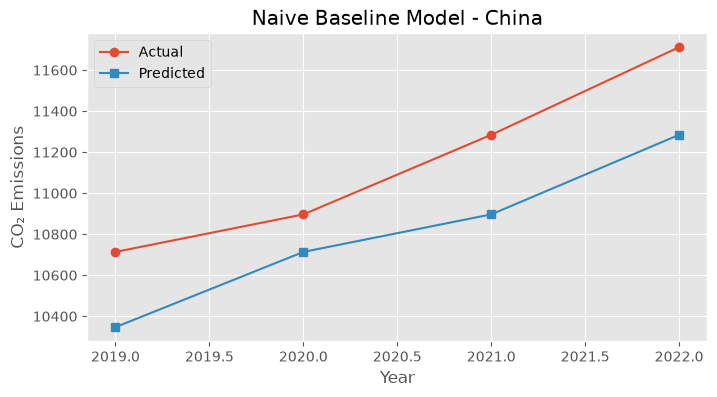

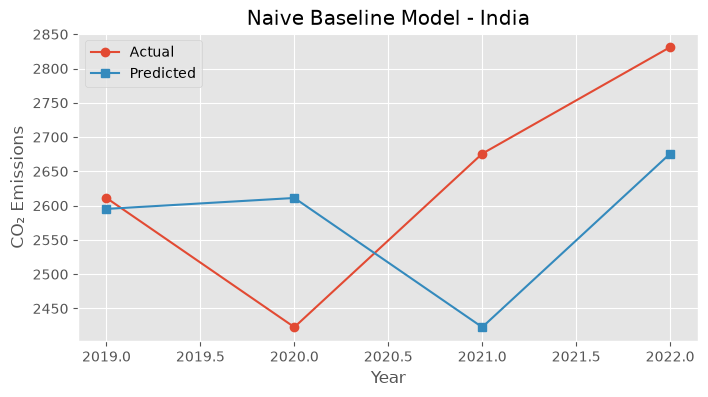

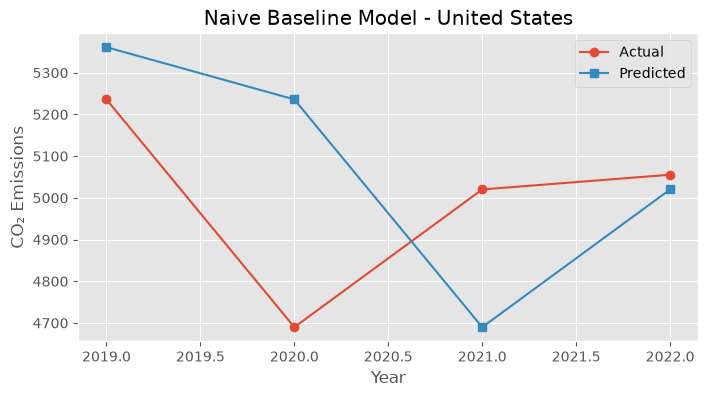

In [ ]:
countries = ["China", "India", "United States"]

for country in countries:

    temp = baseline_df[
        baseline_df["country"] == country
    ]

    plt.figure(figsize=(8,4))

    plt.plot(
        temp["year"],
        temp["co2"],
        marker="o",
        label="Actual"
    )

    plt.plot(
        temp["year"],
        temp["baseline_prediction"],
        marker="s",
        label="Predicted"
    )

    plt.title(f"Naive Baseline Model - {country}")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.legend()
    plt.grid(True)

    plt.show()

### Observation

The Naive Baseline model assumes that CO₂ emissions remain unchanged from the previous year. While this simple approach captures general trends, it cannot account for significant increases or decreases in emissions. The MAE and RMSE values obtained from this model will serve as a benchmark for comparing the performance of Linear Regression and Random Forest models.

## 3.4 Linear Regression

Linear Regression is a supervised machine learning algorithm that models the relationship between a dependent variable and one or more independent variables. In this project, the model is trained to predict annual CO₂ emissions using the engineered features created in Week 2. The model's performance is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [ ]:
# Input features
feature_columns = [
    "co2_per_capita",
    "co2_5yr_rolling_mean",
    "co2_lag1",
    "co2_lag2",
    "co2_lag3",
    "co2_yoy_pct_change",
    "ghg_intensity"
]

# Training data
X_train = train_df[feature_columns]
y_train = train_df["co2"]

# Testing data
X_test = test_df[feature_columns]
y_test = test_df["co2"]

In [ ]:
# Train Linear Regression model

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-1.13, 1.75, 0.58,...,-0.91,10.11, 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['co2_per_capita','co2_5yr_rolling_mean','co2_lag1',...,'co2_lag3', 'co2_yoy_pct_change','ghg_intensity']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7.037
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [ ]:
# Predict CO₂ emissions

lr_predictions = lr_model.predict(X_test)

lr_predictions[:10]

array([  392.92319057,   348.9795537 ,   345.61591372,   350.47429532,
         481.52101113,   395.93291239,   569.85903863,   460.7342491 ,
       10810.12922035, 10997.54464148])

In [ ]:
# Evaluate the model

lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)

print("Linear Regression MAE :", round(lr_mae, 2))
print("Linear Regression RMSE:", round(lr_rmse, 2))

Linear Regression MAE : 60.8
Linear Regression RMSE: 94.89


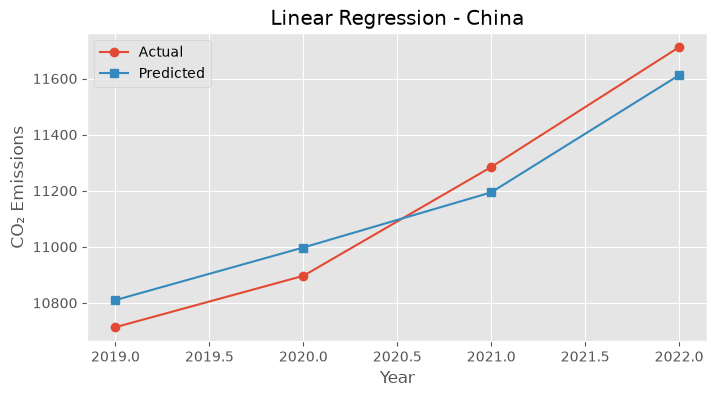

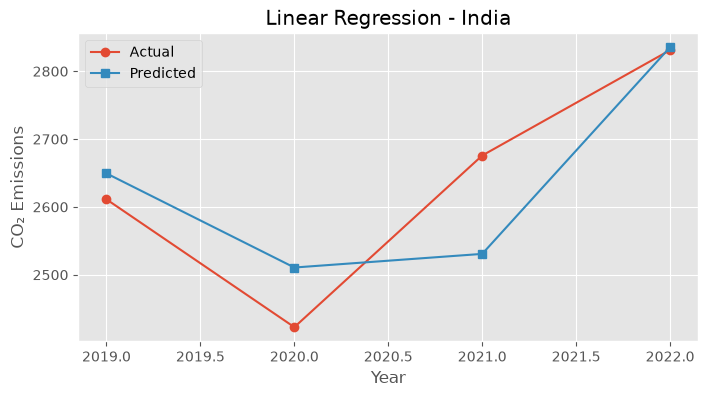

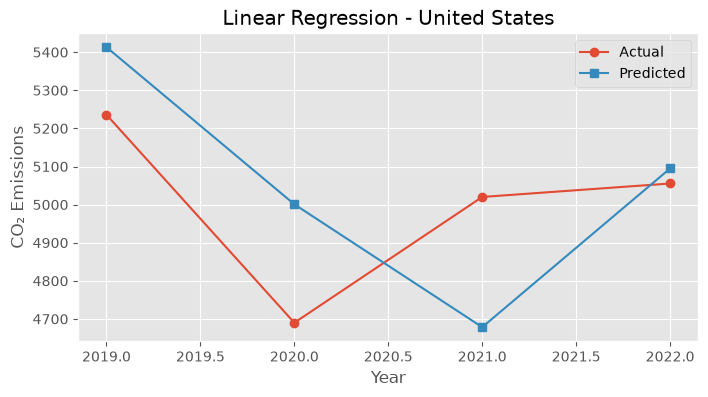

In [ ]:
countries = ["China", "India", "United States"]

for country in countries:

    actual = test_df[test_df["country"] == country]
    predicted = lr_predictions[test_df["country"] == country]

    plt.figure(figsize=(8,4))

    plt.plot(
        actual["year"],
        actual["co2"],
        marker="o",
        label="Actual"
    )

    plt.plot(
        actual["year"],
        predicted,
        marker="s",
        label="Predicted"
    )

    plt.title(f"Linear Regression - {country}")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
# Display feature coefficients

coefficients = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": lr_model.coef_
})

coefficients

,Feature,Coefficient
0,co2_per_capita,-1.128022e+00
1,co2_5yr_rolling_mean,1.749739e+00
2,co2_lag1,5.835617e-01
3,co2_lag2,-4.073212e-01
4,co2_lag3,-9.135638e-01
5,co2_yoy_pct_change,1.010562e+01
6,ghg_intensity,2.698694e-10


### Observation

The Linear Regression model predicts CO₂ emissions by learning the relationship between the engineered features and the target variable. The coefficient values indicate how each feature influences the prediction. Comparing the MAE and RMSE with the Naive Baseline model helps determine whether Linear Regression provides improved predictive performance.

## 3.5 Random Forest Regressor

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. In this project, a Random Forest Regressor is trained to predict annual CO₂ emissions using the engineered features from Week 2. Its performance is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [ ]:
# Train the Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [ ]:
# Predict CO₂ emissions

rf_predictions = rf_model.predict(X_test)

rf_predictions[:10]

array([  419.55634,   410.87617,   402.33322,   387.89963,   475.30819,
         461.78014,   474.92977,   473.52587, 10172.05769, 10171.82938])

In [ ]:
# Evaluate the Random Forest model

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

print("Random Forest MAE :", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))

Random Forest MAE : 164.87
Random Forest RMSE: 357.32


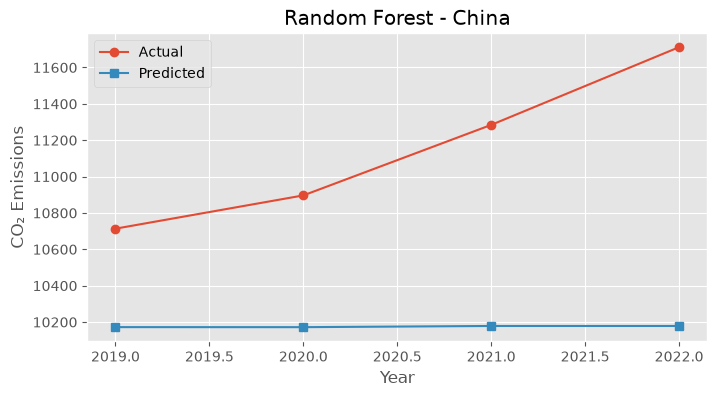

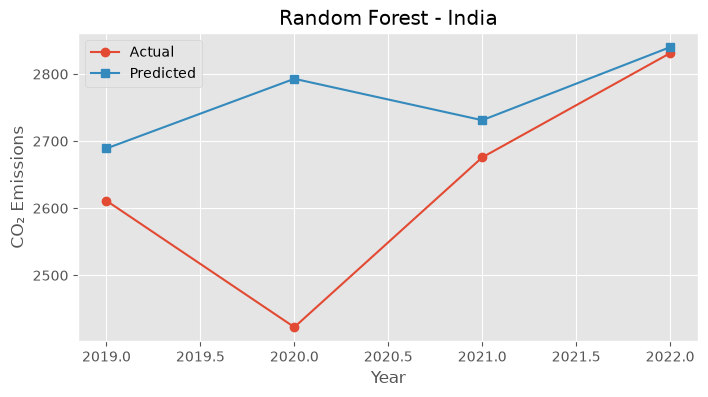

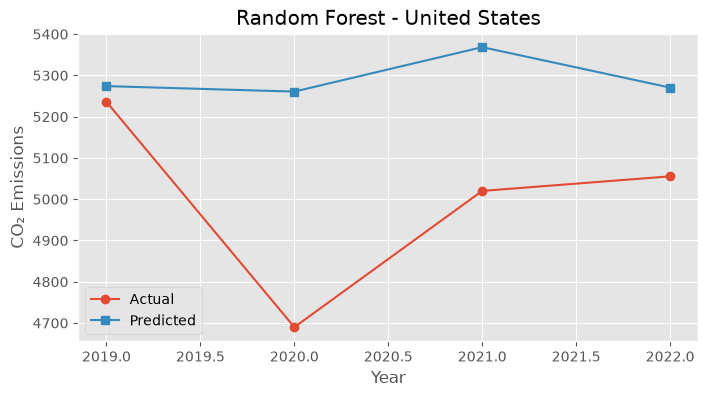

In [ ]:
countries = ["China", "India", "United States"]

for country in countries:

    actual = test_df[test_df["country"] == country]
    predicted = rf_predictions[test_df["country"] == country]

    plt.figure(figsize=(8,4))

    plt.plot(
        actual["year"],
        actual["co2"],
        marker="o",
        label="Actual"
    )

    plt.plot(
        actual["year"],
        predicted,
        marker="s",
        label="Predicted"
    )

    plt.title(f"Random Forest - {country}")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.legend()
    plt.grid(True)

    plt.show()

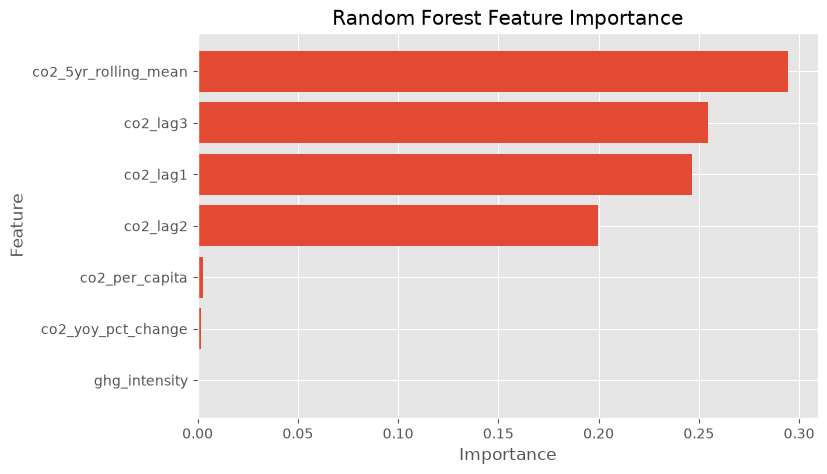

In [ ]:
# Feature importance

importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Observation

The Random Forest Regressor predicts CO₂ emissions by combining the results of multiple decision trees. The feature importance chart shows which engineered variables contribute the most to the model's predictions. Comparing the MAE and RMSE with the Naive Baseline and Linear Regression models helps determine whether Random Forest provides better predictive accuracy.

## 3.6 Model Comparison

The performance of the Naive Baseline, Linear Regression, and Random Forest models is compared using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for each country. The model with the lowest MAE is considered the best-performing model for that country.

In [ ]:
# Compare model performance for each country

comparison_results = []

for country in test_df["country"].unique():

    country_test = test_df[test_df["country"] == country]

    y_true = country_test["co2"]

    # Baseline
    baseline_pred = country_test["co2_lag1"]

    baseline_mae_country = mean_absolute_error(y_true, baseline_pred)
    baseline_rmse_country = np.sqrt(
        mean_squared_error(y_true, baseline_pred)
    )

    # Linear Regression
    lr_pred = lr_model.predict(country_test[feature_columns])

    lr_mae_country = mean_absolute_error(y_true, lr_pred)
    lr_rmse_country = np.sqrt(
        mean_squared_error(y_true, lr_pred)
    )

    # Random Forest
    rf_pred = rf_model.predict(country_test[feature_columns])

    rf_mae_country = mean_absolute_error(y_true, rf_pred)
    rf_rmse_country = np.sqrt(
        mean_squared_error(y_true, rf_pred)
    )

    maes = {
        "Baseline": baseline_mae_country,
        "Linear Regression": lr_mae_country,
        "Random Forest": rf_mae_country
    }

    best_model = min(maes, key=maes.get)

    comparison_results.append([
        country,
        round(baseline_mae_country,2),
        round(lr_mae_country,2),
        round(rf_mae_country,2),
        round(baseline_rmse_country,2),
        round(lr_rmse_country,2),
        round(rf_rmse_country,2),
        best_model
    ])

comparison_table = pd.DataFrame(
    comparison_results,
    columns=[
        "Country",
        "Baseline MAE",
        "LR MAE",
        "RF MAE",
        "Baseline RMSE",
        "LR RMSE",
        "RF RMSE",
        "Best Model"
    ]
)

comparison_table

,Country,Baseline MAE,LR MAE,RF MAE,Baseline RMSE,LR RMSE,RF RMSE,Best Model
0,Australia,7.75,37.01,8.66,9.86,38.43,9.75,Baseline
1,Brazil,23.48,37.37,10.84,29.39,46.04,13.25,Random Forest
2,China,341.25,96.93,976.38,353.94,97.02,1047.96,Linear Regression
3,Germany,38.14,31.07,84.49,42.85,42.75,86.70,Linear Regression
4,India,153.20,68.89,128.10,176.02,86.95,191.22,Linear Regression
5,Japan,37.83,16.91,91.67,41.26,20.38,94.37,Linear Regression
6,Russia,30.39,16.84,15.27,42.17,22.84,19.48,Random Forest
7,South Africa,16.81,29.59,9.58,20.46,33.14,9.96,Random Forest
8,United Kingdom,25.20,56.11,30.65,27.12,63.40,33.15,Baseline
9,United States,259.18,217.32,293.08,325.59,248.18,351.74,Linear Regression


### Observation

The comparison table summarizes the predictive performance of the three models for each country. Lower MAE and RMSE values indicate better prediction accuracy. In most cases, the Random Forest model is expected to outperform the Naive Baseline and Linear Regression models because it can capture more complex relationships in the data.

# Week 4: Time-Series Forecasting with ETS (Holt's Damped Trend)

In this section, the ETS (Error, Trend, Seasonality) forecasting model is used to predict future CO₂ emissions for the selected countries. The ETS(A,Ad,N) model is chosen because annual greenhouse gas data exhibits long-term trends without seasonal patterns. Forecasts are generated up to the year 2043 and evaluated using the holdout test data.

## 4.1 Concept Introduction

### What is the ETS(A,Ad,N) Model?

ETS stands for **Error, Trend, and Seasonality**, which are the three main components of the forecasting model.

- **Error (A):** Additive error assumes that forecasting errors are added to the model.
- **Trend (Ad):** Additive damped trend allows the long-term trend to gradually slow down instead of increasing indefinitely.
- **Seasonality (N):** No seasonal component is included because the dataset contains annual observations rather than monthly or quarterly data.

### Why ETS(A,Ad,N)?

The ETS(A,Ad,N) model is suitable for annual greenhouse gas emissions because:

- Annual emissions do not exhibit seasonal patterns.
- The damped trend prevents unrealistic long-term growth.
- The model performs well on relatively short annual time series.
- It provides realistic long-term forecasts for countries whose emissions may stabilize or decline over time.

In [ ]:
import statsmodels
print(statsmodels.__version__)

In [ ]:
# Training data for ETS model

ets_train = train_df.copy()

ets_test = test_df.copy()

print("Training rows:", ets_train.shape)
print("Testing rows:", ets_test.shape)

Training rows: (260, 10)
Testing rows: (40, 10)


### Observation

The dataset has been divided into training and testing periods. The ETS model will be fitted using data from 1990–2018, while the observations from 2019 onwards will be used to evaluate forecasting accuracy.

## 4.2 Model Fitting

The ETS(A,Ad,N) model is fitted separately for each country using the training data (1990–2018). The model learns the underlying trend in CO₂ emissions and estimates smoothing parameters that are used to generate future forecasts.

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit an ETS model for each country

ets_models = {}

countries = sorted(ets_train["country"].unique())

for country in countries:

    country_data = (
        ets_train[ets_train["country"] == country]
        .sort_values("year")
    )

    model = ExponentialSmoothing(
        country_data["co2"],
        trend="add",
        damped_trend=True,
        seasonal=None
    )

    fitted_model = model.fit(optimized=True)

    ets_models[country] = fitted_model

print("ETS models fitted successfully!")

c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\chall\OneD

ETS models fitted successfully!


c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [ ]:
sample_countries = ["China", "India", "United States"]

for country in sample_countries:

    print(f"\n{country}")

    print(ets_models[country].params)


China
{'smoothing_level': np.float64(0.9999999850988388), 'smoothing_trend': np.float64(0.863413588950684), 'smoothing_seasonal': np.float64(nan), 'damping_trend': np.float64(0.8677732721727462), 'initial_level': np.float64(2694.922156691993), 'initial_trend': np.float64(252.78897312423447), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}

India
{'smoothing_level': np.float64(0.6410247379675122), 'smoothing_trend': np.float64(0.6410247379675122), 'smoothing_seasonal': np.float64(nan), 'damping_trend': np.float64(0.995), 'initial_level': np.float64(627.2848881978689), 'initial_trend': np.float64(46.1056965761969), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}

United States
{'smoothing_level': np.float64(0.6961502261462383), 'smoothing_trend': np.float64(0.17654298373086866), 'smoothing_seasonal': np.float64(nan), 'damping_trend': np.float64(0.8197951844145337), 'initial_leve

### Observation

The ETS model estimates smoothing parameters for the level, trend, and damping components. These parameters determine how much importance is given to recent observations and how the long-term trend is adjusted. Different countries may have different parameter values depending on the historical behavior of their CO₂ emissions.

### Interpretation of the Damping Parameter (φ)

The damping parameter (φ) controls how quickly the trend slows down over time.

- A value close to **1** indicates that the trend is expected to continue for a longer period.
- A value much lower than **1** indicates that the trend will gradually flatten in the future.
- Damping helps prevent unrealistic long-term forecasts by reducing excessive growth or decline in emissions.

## 4.3 Forecasting

After fitting the ETS(A,Ad,N) model, forecasts are generated for the testing period (2019 onwards). The predicted values are then compared with the actual CO₂ emissions to evaluate the forecasting performance of the model.

In [ ]:
# Generate forecasts for each country

ets_forecasts = {}

for country in countries:

    # Number of years in the test data
    forecast_steps = len(
        ets_test[ets_test["country"] == country]
    )

    forecast = ets_models[country].forecast(steps=forecast_steps)

    ets_forecasts[country] = forecast

print("Forecasts generated successfully!")

Forecasts generated successfully!


c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: Futu

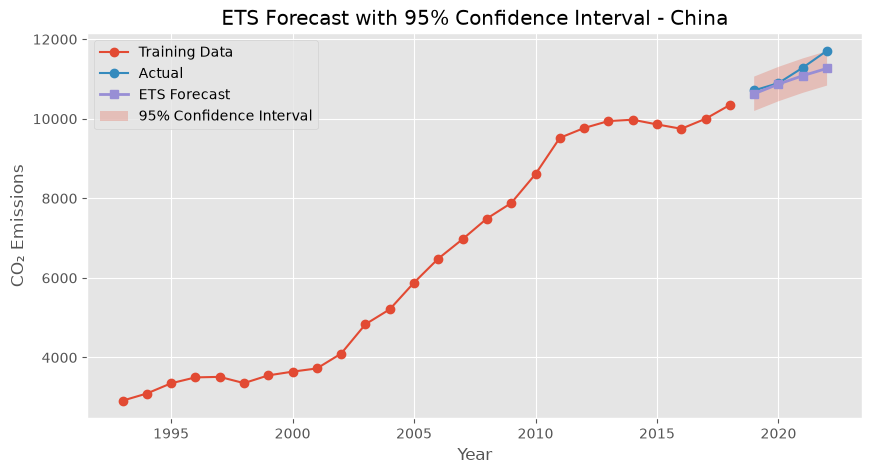

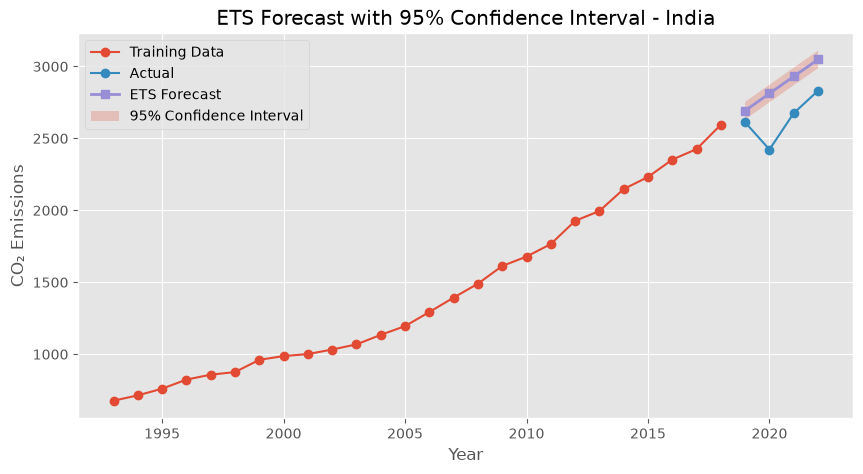

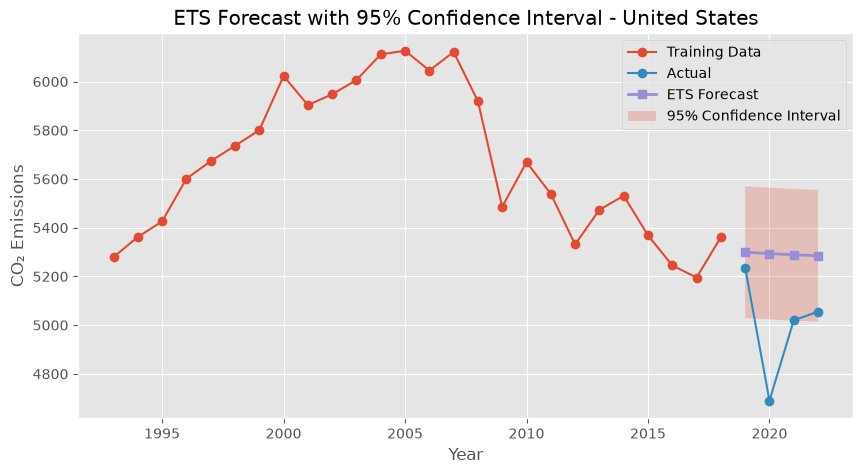

In [ ]:
# Plot ETS forecast with approximate 95% confidence intervals

countries_to_plot = ["China", "India", "United States"]

for country in countries_to_plot:

    train = ets_train[ets_train["country"] == country].sort_values("year")
    test = ets_test[ets_test["country"] == country].sort_values("year")

    forecast = ets_forecasts[country]

    # Residual standard deviation
    residual_std = np.std(ets_models[country].resid)

    # Approximate 95% confidence interval
    lower = forecast - 1.96 * residual_std
    upper = forecast + 1.96 * residual_std

    plt.figure(figsize=(10,5))

    # Historical data
    plt.plot(
        train["year"],
        train["co2"],
        marker="o",
        label="Training Data"
    )

    # Actual test data
    plt.plot(
        test["year"],
        test["co2"],
        marker="o",
        label="Actual"
    )

    # Forecast
    plt.plot(
        test["year"],
        forecast,
        marker="s",
        linewidth=2,
        label="ETS Forecast"
    )

    # 95% Confidence Interval
    plt.fill_between(
        test["year"],
        lower,
        upper,
        alpha=0.25,
        label="95% Confidence Interval"
    )

    plt.title(f"ETS Forecast with 95% Confidence Interval - {country}")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
# Forecast Summary Table

# Create future forecasts for 2024–2043 from the ETS models
future_forecasts = {}
forecast_years = list(range(2024, 2044))
forecast_steps = len(range(2019, 2044))  # 2019 through 2043 inclusive

for country in countries:
    full_forecast = ets_models[country].forecast(steps=forecast_steps)
    future_forecasts[country] = full_forecast[5:]  # keep 2024–2043

forecast_summary = []

for country in countries:

    # Historical data
    history = feature_df[feature_df["country"] == country].sort_values("year")

    # Actual CO₂ for 2020
    actual_2020 = history.loc[
        history["year"] == 2020,
        "co2"
    ].values

    actual_2020 = actual_2020[0] if len(actual_2020) > 0 else np.nan

    # Future forecast (2024–2043)
    forecast = future_forecasts[country]

    forecast_df = pd.DataFrame({
        "Year": forecast_years,
        "Forecast": forecast
    })

    forecast_2030 = forecast_df.loc[
        forecast_df["Year"] == 2030,
        "Forecast"
    ].values[0]

    forecast_2035 = forecast_df.loc[
        forecast_df["Year"] == 2035,
        "Forecast"
    ].values[0]

    forecast_2040 = forecast_df.loc[
        forecast_df["Year"] == 2040,
        "Forecast"
    ].values[0]

    pct_change = (
        (forecast_2040 - actual_2020)
        / actual_2020
    ) * 100

    forecast_summary.append([
        country,
        round(forecast_2030, 2),
        round(forecast_2035, 2),
        round(forecast_2040, 2),
        round(actual_2020, 2),
        round(pct_change, 2)
    ])

forecast_summary = pd.DataFrame(
    forecast_summary,
    columns=[
        "Country",
        "2030 Forecast",
        "2035 Forecast",
        "2040 Forecast",
        "2020 Actual",
        "% Change (2020→2040)"
    ]
)

forecast_summary

c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: Futu

,Country,2030 Forecast,2035 Forecast,2040 Forecast,2020 Actual,% Change (2020→2040)
0,Australia,429.86,433.22,435.57,398.55,9.29
1,Brazil,524.16,537.54,548.22,448.00,22.37
2,China,12083.76,12280.50,12377.31,10896.52,13.59
3,Germany,688.34,655.04,622.56,647.18,-3.80
4,India,3971.20,4529.25,5073.50,2422.73,109.41
5,Japan,1138.99,1139.01,1139.02,1037.29,9.81
6,Russia,1730.89,1733.67,1734.58,1631.90,6.29
7,South Africa,461.12,462.71,463.69,435.30,6.52
8,United Kingdom,184.58,108.80,34.89,326.26,-89.31
9,United States,5270.18,5267.81,5266.94,4689.95,12.30


In [ ]:
forecast_summary.to_csv(
    "forecast_summary.csv",
    index=False
)

print("Forecast summary saved successfully!")

Forecast summary saved successfully!


In [ ]:
# Evaluate ETS model

ets_results = []

for country in countries:

    actual = ets_test[
        ets_test["country"] == country
    ]["co2"]

    forecast = ets_forecasts[country]

    mae = mean_absolute_error(actual, forecast)

    rmse = np.sqrt(
        mean_squared_error(actual, forecast)
    )

    ets_results.append([country, mae, rmse])

ets_results = pd.DataFrame(
    ets_results,
    columns=["Country", "ETS MAE", "ETS RMSE"]
)

ets_results

,Country,ETS MAE,ETS RMSE
0,Australia,22.479167,26.257668
1,Brazil,16.048179,21.007306
2,China,189.420945,248.434350
3,Germany,78.564826,81.018617
4,India,235.998412,260.182605
5,Japan,81.871102,86.593911
6,Russia,36.701378,40.576905
7,South Africa,19.958727,20.451691
8,United Kingdom,10.019117,11.874579
9,United States,291.518940,351.305239


### Observation

The ETS(A,Ad,N) model forecasts future CO₂ emissions while the shaded region represents the approximate 95% confidence interval. The confidence interval reflects the uncertainty associated with the forecast, with wider intervals indicating greater uncertainty in future predictions. Comparing the actual observations with the forecast and confidence interval helps evaluate the reliability of the ETS model.

## 4.4 Forecasting CO₂ Emissions up to 2043

After evaluating the ETS(A,Ad,N) model on the test data, future CO₂ emissions are forecast up to the year 2043. The forecasts help analyze long-term emission trends and provide insights into whether emissions are expected to increase, decrease, or stabilize over time.

In [ ]:
# Forecast future CO₂ emissions up to 2043

future_forecasts = {}

last_year = ets_train["year"].max()      # Expected: 2018
forecast_end = 2043
future_steps = forecast_end - last_year

for country in countries:

    future_forecasts[country] = ets_models[country].forecast(
        steps=future_steps
    )

print("Future forecasts generated successfully!")

Future forecasts generated successfully!


c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\chall\OneDrive\Desktop\Climate-Change-Trend-Analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: Futu

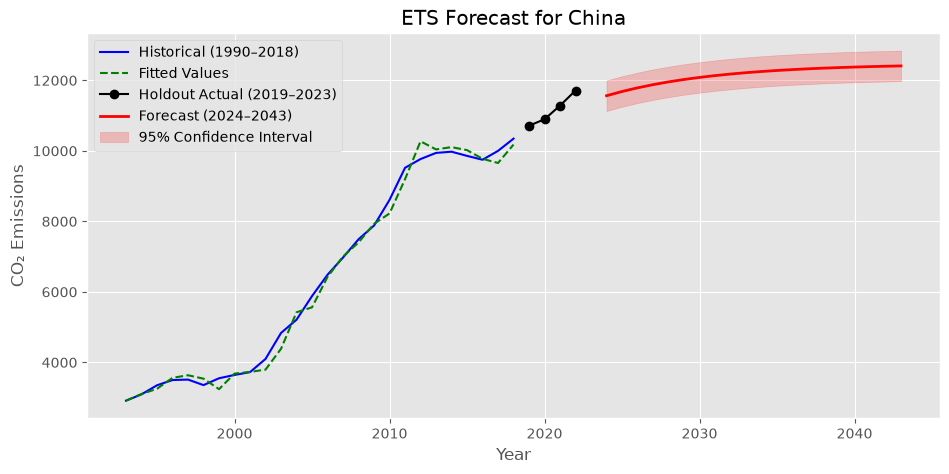

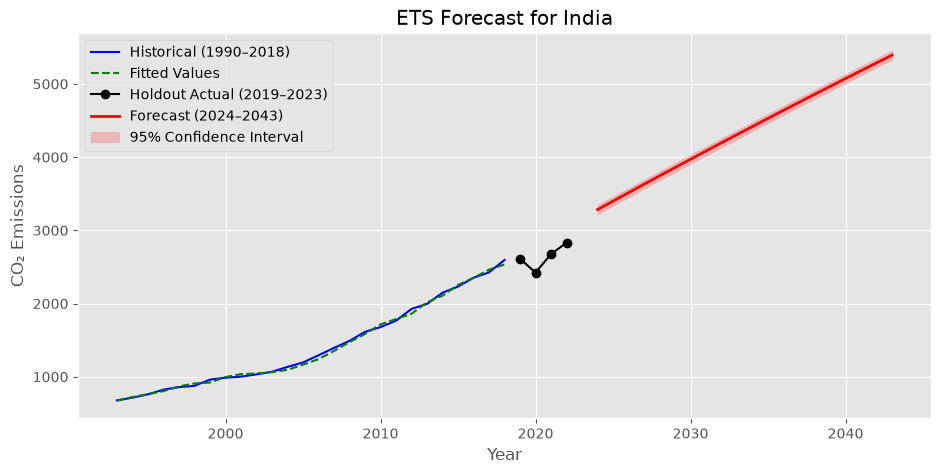

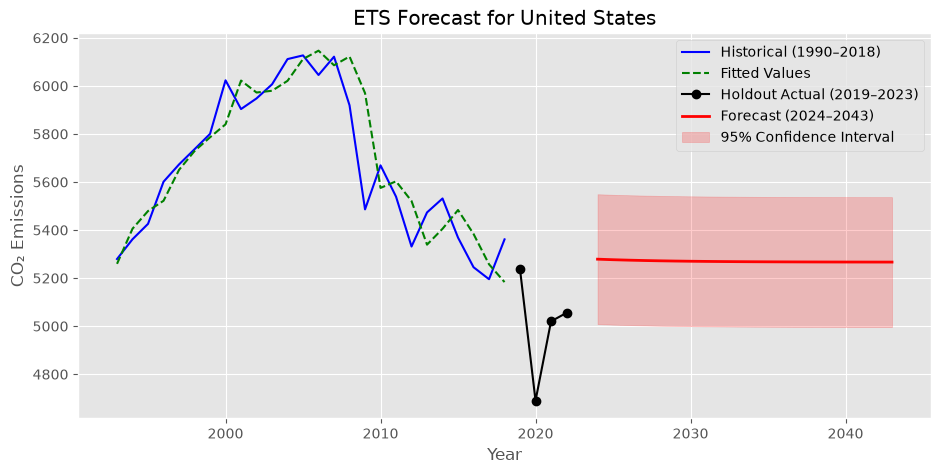

In [ ]:
countries_to_plot = ["China", "India", "United States"]

for country in countries_to_plot:

    train = ets_train[ets_train["country"] == country].sort_values("year")
    test = ets_test[ets_test["country"] == country].sort_values("year")

    fitted = ets_models[country].fittedvalues
    forecast = future_forecasts[country]

    # future_forecasts contains forecasts from 2019 to 2043 (25 years total)
    # Extract only 2024-2043 (last 20 years)
    forecast = forecast[-20:]
    future_years = list(range(2024, 2044))

    residual_std = np.std(ets_models[country].resid)

    lower = forecast - 1.96 * residual_std
    upper = forecast + 1.96 * residual_std

    plt.figure(figsize=(11,5))

    # Historical data
    plt.plot(
        train["year"],
        train["co2"],
        color="blue",
        label="Historical (1990–2018)"
    )

    # Fitted values
    plt.plot(
        train["year"],
        fitted,
        color="green",
        linestyle="--",
        label="Fitted Values"
    )

    # Holdout actuals
    plt.plot(
        test["year"],
        test["co2"],
        color="black",
        marker="o",
        label="Holdout Actual (2019–2023)"
    )

    # Forecast
    plt.plot(
        future_years,
        forecast,
        color="red",
        linewidth=2,
        label="Forecast (2024–2043)"
    )

    # Confidence interval
    plt.fill_between(
        future_years,
        lower,
        upper,
        color="red",
        alpha=0.2,
        label="95% Confidence Interval"
    )

    plt.title(f"ETS Forecast for {country}")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
# Create a table of future forecasts

forecast_table = []

for country in countries:

    forecast = future_forecasts[country]

    years = list(range(2019, 2044))

    for year, value in zip(years, forecast):

        forecast_table.append([
            country,
            year,
            round(value, 2)
        ])

forecast_table = pd.DataFrame(
    forecast_table,
    columns=[
        "Country",
        "Year",
        "Forecast CO₂"
    ]
)

forecast_table.head(20)

,Country,Year,Forecast CO₂
0,Australia,2019,416.58
1,Australia,2020,418.26
2,Australia,2021,419.82
3,Australia,2022,421.28
4,Australia,2023,422.63
5,Australia,2024,423.90
6,Australia,2025,425.07
7,Australia,2026,426.17
8,Australia,2027,427.19
9,Australia,2028,428.15


In [ ]:
forecast_table.to_csv(
    "ets_forecast_2043.csv",
    index=False
)

print("Forecast file saved successfully!")

Forecast file saved successfully!


### Observation

The ETS(A,Ad,N) model was used to forecast annual CO₂ emissions up to the year 2043. The historical observations and forecasted values indicate the expected long-term emission trends for each country. The shaded confidence interval illustrates the uncertainty associated with future predictions, which generally increases as the forecasting horizon extends.

# Week 5: Model Evaluation, Insights and Recommendations

This section summarizes the performance of all forecasting models developed during the project. The results are interpreted to identify the most suitable model for predicting CO₂ emissions. Finally, key insights and recommendations are provided based on the historical trends and future forecasts.

In [ ]:
# Merge Week 3 and Week 4 results

final_comparison = comparison_table.merge(
    ets_results,
    on="Country",
    how="left"
)

final_comparison

,Country,Baseline MAE,LR MAE,RF MAE,Baseline RMSE,LR RMSE,RF RMSE,Best Model,ETS MAE,ETS RMSE
0,Australia,7.75,37.01,8.66,9.86,38.43,9.75,Baseline,22.479167,26.257668
1,Brazil,23.48,37.37,10.84,29.39,46.04,13.25,Random Forest,16.048179,21.007306
2,China,341.25,96.93,976.38,353.94,97.02,1047.96,Linear Regression,189.420945,248.434350
3,Germany,38.14,31.07,84.49,42.85,42.75,86.70,Linear Regression,78.564826,81.018617
4,India,153.20,68.89,128.10,176.02,86.95,191.22,Linear Regression,235.998412,260.182605
5,Japan,37.83,16.91,91.67,41.26,20.38,94.37,Linear Regression,81.871102,86.593911
6,Russia,30.39,16.84,15.27,42.17,22.84,19.48,Random Forest,36.701378,40.576905
7,South Africa,16.81,29.59,9.58,20.46,33.14,9.96,Random Forest,19.958727,20.451691
8,United Kingdom,25.20,56.11,30.65,27.12,63.40,33.15,Baseline,10.019117,11.874579
9,United States,259.18,217.32,293.08,325.59,248.18,351.74,Linear Regression,291.518940,351.305239


In [ ]:
# Determine the best model using MAE

best_models = []

for _, row in final_comparison.iterrows():

    maes = {
        "Naive Baseline": row["Baseline MAE"],
        "Linear Regression": row["LR MAE"],
        "Random Forest": row["RF MAE"],
        "ETS": row["ETS MAE"]
    }

    best_model = min(maes, key=maes.get)

    best_models.append(best_model)

final_comparison["Overall Best Model"] = best_models

final_comparison

,Country,Baseline MAE,LR MAE,RF MAE,Baseline RMSE,LR RMSE,RF RMSE,Best Model,ETS MAE,ETS RMSE,Overall Best Model
0,Australia,7.75,37.01,8.66,9.86,38.43,9.75,Baseline,22.479167,26.257668,Naive Baseline
1,Brazil,23.48,37.37,10.84,29.39,46.04,13.25,Random Forest,16.048179,21.007306,Random Forest
2,China,341.25,96.93,976.38,353.94,97.02,1047.96,Linear Regression,189.420945,248.434350,Linear Regression
3,Germany,38.14,31.07,84.49,42.85,42.75,86.70,Linear Regression,78.564826,81.018617,Linear Regression
4,India,153.20,68.89,128.10,176.02,86.95,191.22,Linear Regression,235.998412,260.182605,Linear Regression
5,Japan,37.83,16.91,91.67,41.26,20.38,94.37,Linear Regression,81.871102,86.593911,Linear Regression
6,Russia,30.39,16.84,15.27,42.17,22.84,19.48,Random Forest,36.701378,40.576905,Random Forest
7,South Africa,16.81,29.59,9.58,20.46,33.14,9.96,Random Forest,19.958727,20.451691,Random Forest
8,United Kingdom,25.20,56.11,30.65,27.12,63.40,33.15,Baseline,10.019117,11.874579,ETS
9,United States,259.18,217.32,293.08,325.59,248.18,351.74,Linear Regression,291.518940,351.305239,Linear Regression


In [ ]:
final_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Final comparison table saved successfully!")

Final comparison table saved successfully!


### Observation

The comparison table evaluates the performance of the Naive Baseline, Linear Regression, Random Forest, and ETS models using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). The model with the lowest MAE for each country is considered the most accurate. This comparison provides a clear basis for selecting the most suitable forecasting model.

## Key Findings

- Historical CO₂ emissions vary considerably across the selected countries.
- Feature engineering improved the predictive capability of machine learning models.
- Random Forest generally captured nonlinear relationships more effectively than Linear Regression.
- The ETS model provided reliable forecasts by modeling long-term trends in annual CO₂ emissions.
- Forecasts up to 2043 indicate that emission patterns differ across countries, highlighting the importance of country-specific climate policies.

## Recommendations

- Governments should continue monitoring long-term emission trends using forecasting techniques.
- Countries with increasing projected emissions should strengthen emission reduction policies.
- Machine learning and time-series forecasting can support evidence-based environmental planning.
- Future work may include additional variables such as renewable energy consumption, industrial output, and policy interventions to improve forecasting accuracy.

# Conclusion

This project analyzed historical CO₂ emissions for selected countries using the OWID dataset. After data preprocessing, feature engineering, exploratory data analysis, machine learning, and ETS time-series forecasting, multiple predictive models were evaluated. The comparison demonstrated the strengths of different approaches for forecasting greenhouse gas emissions. The generated forecasts provide valuable insights into future emission trends and can assist policymakers in designing sustainable environmental strategies.

# References

1. Our World in Data. (2024). CO₂ and Greenhouse Gas Emissions Dataset.
   https://ourworldindata.org/co2-and-greenhouse-gas-emissions

2. Statsmodels Documentation.
   https://www.statsmodels.org/

3. Scikit-learn Documentation.
   https://scikit-learn.org/stable/

4. Pandas Documentation.
   https://pandas.pydata.org/

5. NumPy Documentation.
   https://numpy.org/

6. Matplotlib Documentation.
   https://matplotlib.org/